# Rossmann Store Sales — Interpretation & Promotion Impact

**Goal:** Explain what drives the final XGBoost model's forecasts using SHAP, and quantify the
promotion/holiday lift more rigorously than a simple group-average comparison — by isolating
the effect while holding other factors (store, season, day of week) constant.

Sections:
1. Rebuild pipeline and retrain final model
2. SHAP global feature importance
3. SHAP dependence: Promo effect
4. SHAP dependence: Holiday effect
5. Counterfactual promo lift (model-based, controlling for other factors)
6. Individual forecast explanation
7. Key takeaways and final summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from xgboost import XGBRegressor

RANDOM_STATE = 42
shap.initjs()

## 1. Rebuild Pipeline and Retrain Final Model

Same steps as notebook 03, repeated so this notebook can run independently.

In [3]:
train = pd.read_csv('../data/train.csv', parse_dates=['Date'], low_memory=False)
store = pd.read_csv('../data/store.csv')

df = train.merge(store, on='Store', how='left')
df = df[df['Open'] == 1].copy()
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

for lag in [1, 7, 14]:
    df[f'Sales_lag_{lag}'] = df.groupby('Store')['Sales'].shift(lag)

for window in [7, 30]:
    df[f'Sales_rollmean_{window}'] = (
        df.groupby('Store')['Sales']
          .transform(lambda s: s.shift(1).rolling(window).mean())
    )

df = df.dropna(subset=['Sales_lag_14', 'Sales_rollmean_30']).reset_index(drop=True)

df['StoreType'] = df['StoreType'].astype('category').cat.codes
df['Assortment'] = df['Assortment'].astype('category').cat.codes
df['StateHoliday'] = df['StateHoliday'].astype('category').cat.codes

train_cutoff = pd.Timestamp('2015-05-14')
valid_cutoff = pd.Timestamp('2015-06-25')

train_df = df[df['Date'] <= train_cutoff].copy()
valid_df = df[(df['Date'] > train_cutoff) & (df['Date'] <= valid_cutoff)].copy()

feature_cols = [
    'Store', 'DayOfWeek', 'Month', 'Year', 'WeekOfYear', 'IsWeekend',
    'Promo', 'SchoolHoliday', 'StateHoliday', 'StoreType', 'Assortment',
    'CompetitionDistance', 'Promo2',
    'Sales_lag_1', 'Sales_lag_7', 'Sales_lag_14',
    'Sales_rollmean_7', 'Sales_rollmean_30'
]
feature_cols = [c for c in feature_cols if c in df.columns]

X_train, y_train = train_df[feature_cols], train_df['Sales']
X_valid, y_valid = valid_df[feature_cols], valid_df['Sales']

xgb_model = XGBRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

print('Model retrained. Validation shape:', X_valid.shape)

Model retrained. Validation shape: (38555, 18)


## 2. SHAP Global Feature Importance

Sampling for speed, same approach as the diabetes project.

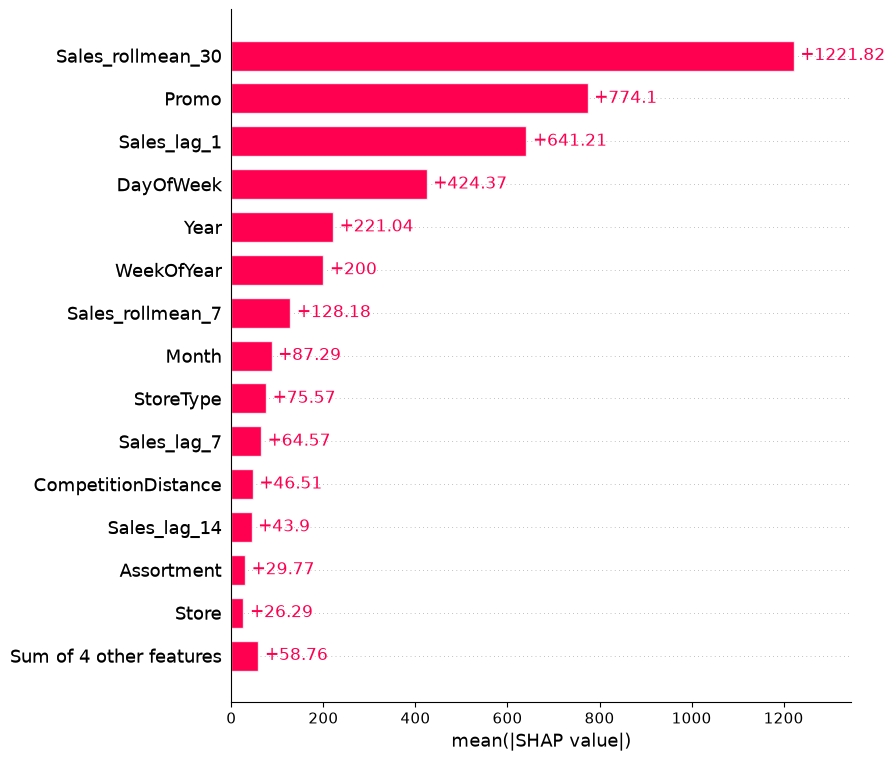

In [4]:
sample_size = 3000
X_sample = X_valid.sample(n=min(sample_size, len(X_valid)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_sample)

shap.plots.bar(shap_values, max_display=15)

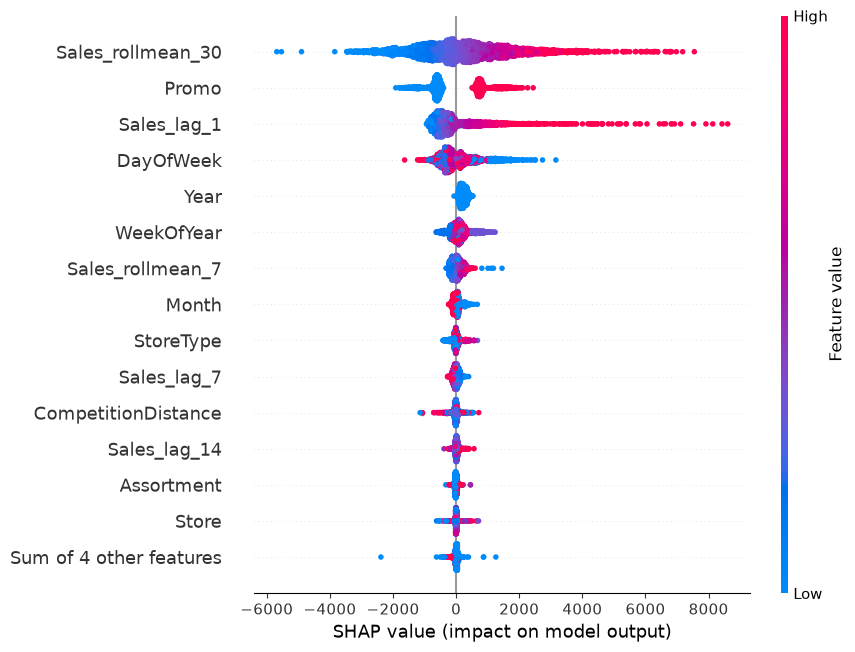

In [5]:
shap.plots.beeswarm(shap_values, max_display=15)

## 3. SHAP Dependence: Promo Effect

Shows how the model's predicted sales change with Promo status, holding the interaction
coloring feature visible for context.

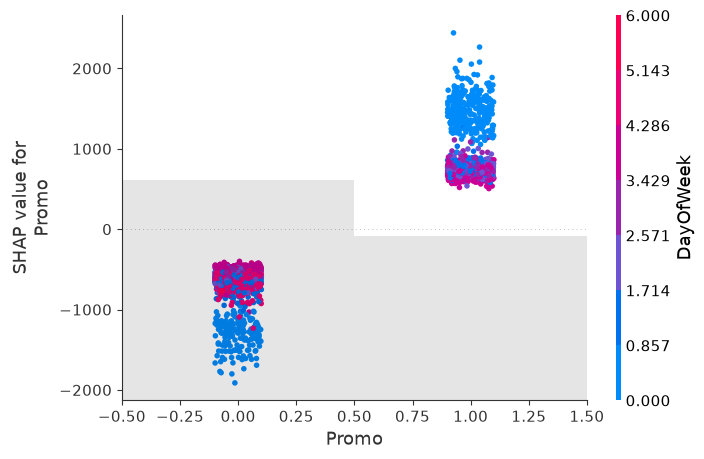

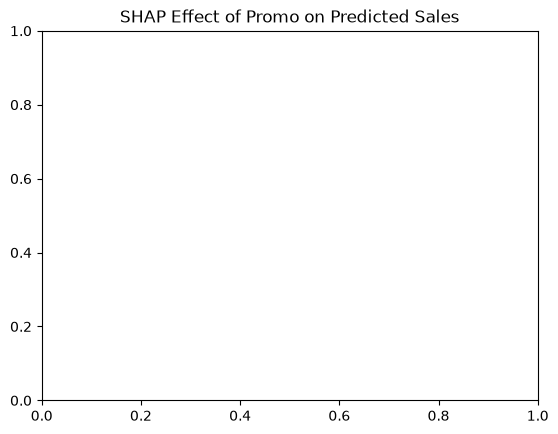

In [6]:
shap.plots.scatter(shap_values[:, 'Promo'], color=shap_values)
plt.title('SHAP Effect of Promo on Predicted Sales')
plt.show()

## 4. SHAP Dependence: Holiday Effect

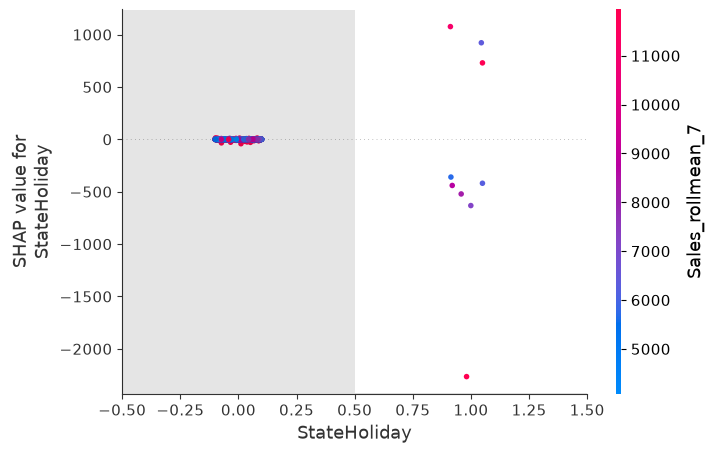

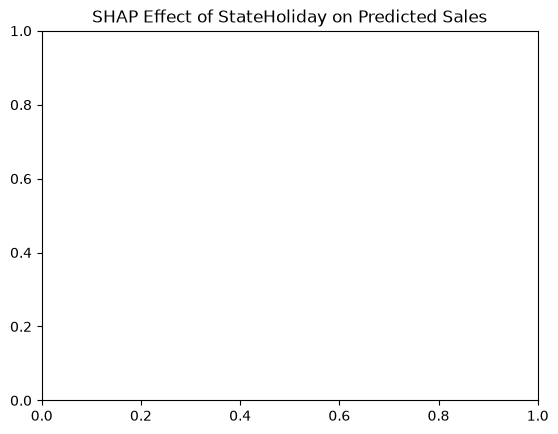

In [7]:
if 'StateHoliday' in X_sample.columns:
    shap.plots.scatter(shap_values[:, 'StateHoliday'], color=shap_values)
    plt.title('SHAP Effect of StateHoliday on Predicted Sales')
    plt.show()

## 5. Counterfactual Promo Lift (Model-Based)

This is a more rigorous version of the simple group-average comparison from notebook 01.
Instead of comparing raw averages (which mixes in whatever stores/seasons happen to run more
promotions), we take the SAME rows, force `Promo=0` for all of them, predict; then force
`Promo=1` for all of them, predict; and compare. This isolates the promo effect while holding
every other factor (store, day of week, season, lag features) fixed.

**Caveat:** this is a model-based counterfactual, not a randomized experiment. It assumes the
model has correctly learned how Promo interacts with other features. It's a reasonable and
commonly-used approach, but is worth stating as an assumption in your write-up rather than
presenting it as definitive causal proof.

In [8]:
X_counterfactual = X_valid.copy()

X_no_promo = X_counterfactual.copy()
X_no_promo['Promo'] = 0
pred_no_promo = xgb_model.predict(X_no_promo)

X_with_promo = X_counterfactual.copy()
X_with_promo['Promo'] = 1
pred_with_promo = xgb_model.predict(X_with_promo)

avg_lift = (pred_with_promo.mean() / pred_no_promo.mean() - 1)
abs_lift = pred_with_promo.mean() - pred_no_promo.mean()

print(f'Average predicted sales WITHOUT promo: {pred_no_promo.mean():.0f}')
print(f'Average predicted sales WITH promo:    {pred_with_promo.mean():.0f}')
print(f'Estimated promo lift (model-based, controlling for other factors): {avg_lift:.1%}')
print(f'Absolute lift per store-day: {abs_lift:.0f}')

Average predicted sales WITHOUT promo: 7024
Average predicted sales WITH promo:    8466
Estimated promo lift (model-based, controlling for other factors): 20.5%
Absolute lift per store-day: 1442


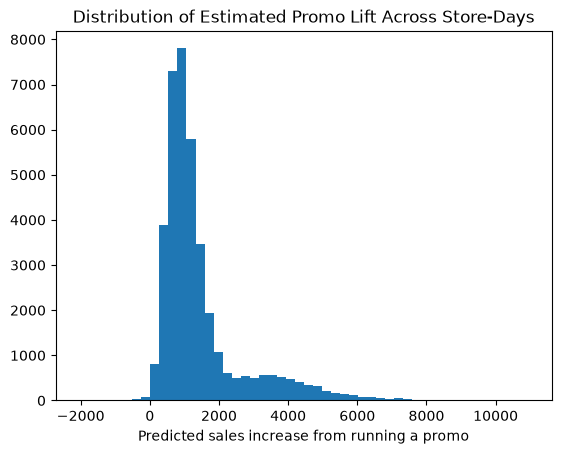

In [9]:
import matplotlib.pyplot as plt

plt.hist(pred_with_promo - pred_no_promo, bins=50)
plt.title('Distribution of Estimated Promo Lift Across Store-Days')
plt.xlabel('Predicted sales increase from running a promo')
plt.show()

## 6. Individual Forecast Explanation

Explain one specific prediction — good for a portfolio screenshot showing real applicability.

Explaining prediction for row index: 0 (from the SHAP sample, not the full validation set)


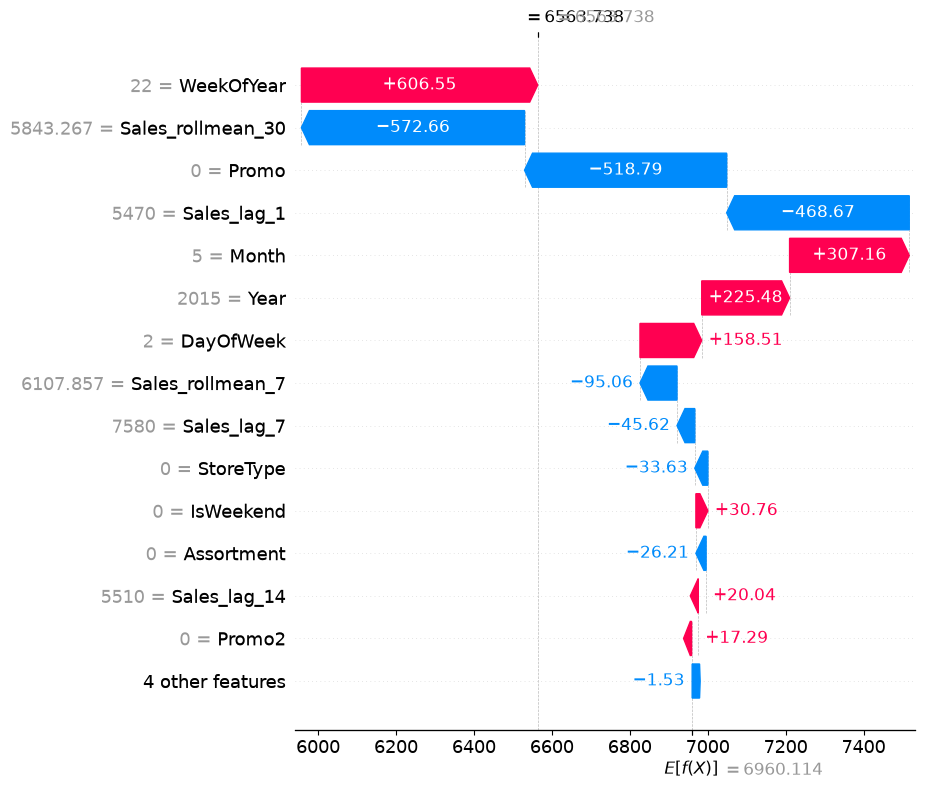

In [10]:
idx = 0
print('Explaining prediction for row index:', idx, '(from the SHAP sample, not the full validation set)')
shap.plots.waterfall(shap_values[idx], max_display=15)